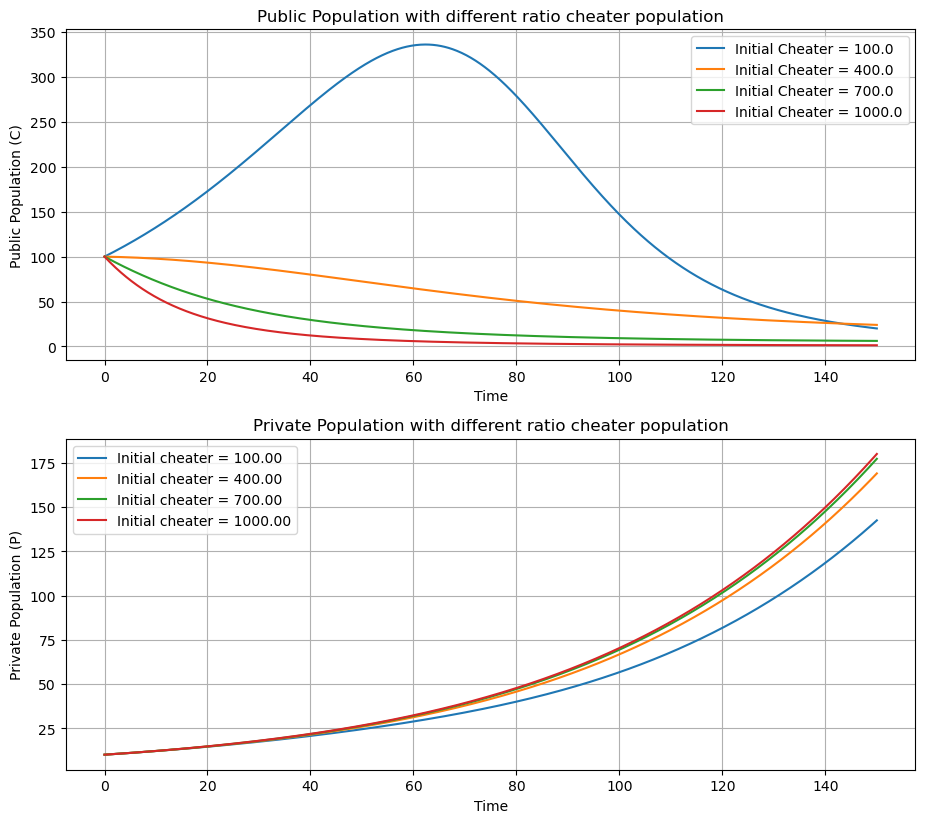

In [55]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of initial populations for defector
D_values = np.linspace(100, 1000, 4)  # D values from 0.1 to 10 (log scale for better spacing)

# Initial conditions
C0, P0 = 100.0, 10.0

# Time grid
t = np.linspace(0, 150, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, D0 in enumerate(D_values):
    y0 = C0, D0, P0  # Set initial conditions with varying D0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for C, D, and P
    plt.subplot(3, 2, 1)
    plt.plot(t, C, label=f'Initial Cheater = {D0:.1f}')
    plt.xlabel('Time')
    plt.ylabel('Public Population (C)')
    plt.title('Public Population with different ratio cheater population')
    plt.grid(True)

    plt.subplot(3, 2, 3)
    plt.plot(t, P, label=f'Initial cheater = {D0:.1f}')
    plt.xlabel('Time')
    plt.ylabel('Private Population (P)')
    plt.title('Private Population with different ratio cheater population')
    plt.grid(True)

# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()
plt.subplot(3, 2, 3)
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Define parameters
rc = 1.0    # Growth rate of public metabolizers
rp = 1.1    # Growth rate of private metabolizers
alpha = 0.5  # Cheaters' benefit from public metabolizers
beta = 0.3   # Competition between public and private metabolizers
eta = 0.4    # Effect of public metabolizers on private metabolizers
nu = 0.2     # Mortality rate of cheaters

# Define the steady-state equations to solve
def steady_state_eqs(vars, rc, rp, alpha, beta, eta, nu):
    C, D, P = vars
    eq1 = rc * C - alpha * C * D - beta * C * P
    eq2 = alpha * C * D - nu * D
    eq3 = rp * P - eta * P * C
    return [eq1, eq2, eq3]

# Initial guesses for the steady-state concentrations
initial_guess = [0.5, 0.2, 0.3]

# Solve for steady-state concentrations
C_star, D_star, P_star = fsolve(steady_state_eqs, initial_guess, args=(rc, rp, alpha, beta, eta, nu))

print(f"Steady-state concentrations:\nC* = {C_star}, D* = {D_star}, P* = {P_star}")

# Define a small perturbation for numerical derivative
delta = 1e-4

# Compute control coefficients for parameter 'alpha'
# Numerical derivative: C_alpha^C = (C*(alpha + delta) - C*) / (delta * alpha)

# Perturb 'alpha' and compute new steady-state concentrations
def compute_control_coefficients(param, param_name):
    param_perturbed = param + delta
    
    # Solve the steady state with the perturbed parameter
    if param_name == 'alpha':
        new_C_star, new_D_star, new_P_star = fsolve(steady_state_eqs, initial_guess, args=(rc, rp, param_perturbed, beta, eta, nu))
    elif param_name == 'rc':
        new_C_star, new_D_star, new_P_star = fsolve(steady_state_eqs, initial_guess, args=(param_perturbed, rp, alpha, beta, eta, nu))
    elif param_name == 'beta':
        new_C_star, new_D_star, new_P_star = fsolve(steady_state_eqs, initial_guess, args=(rc, rp, alpha, param_perturbed, eta, nu))
    # Add more parameters if needed
    
    # Compute the control coefficients
    C_alpha_C = (new_C_star - C_star) / (delta * param) * param / C_star
    C_alpha_D = (new_D_star - D_star) / (delta * param) * param / D_star
    C_alpha_P = (new_P_star - P_star) / (delta * param) * param / P_star
    
    return C_alpha_C, C_alpha_D, C_alpha_P

# Example: Control coefficients with respect to 'alpha'
C_alpha_C, C_alpha_D, C_alpha_P = compute_control_coefficients(alpha, 'alpha')
print(f"Control Coefficients for 'alpha':\nC_alpha^C = {C_alpha_C}, C_alpha^D = {C_alpha_D}, C_alpha^P = {C_alpha_P}")


Steady-state concentrations:
C* = 0.4000000000022512, D* = 2.0000000000118012, P* = -1.3213613804036187e-13
Control Coefficients for 'alpha':
C_alpha^C = -1.9996001817372415, C_alpha^D = -1.9996001866777442, C_alpha^P = -18127.26036604944


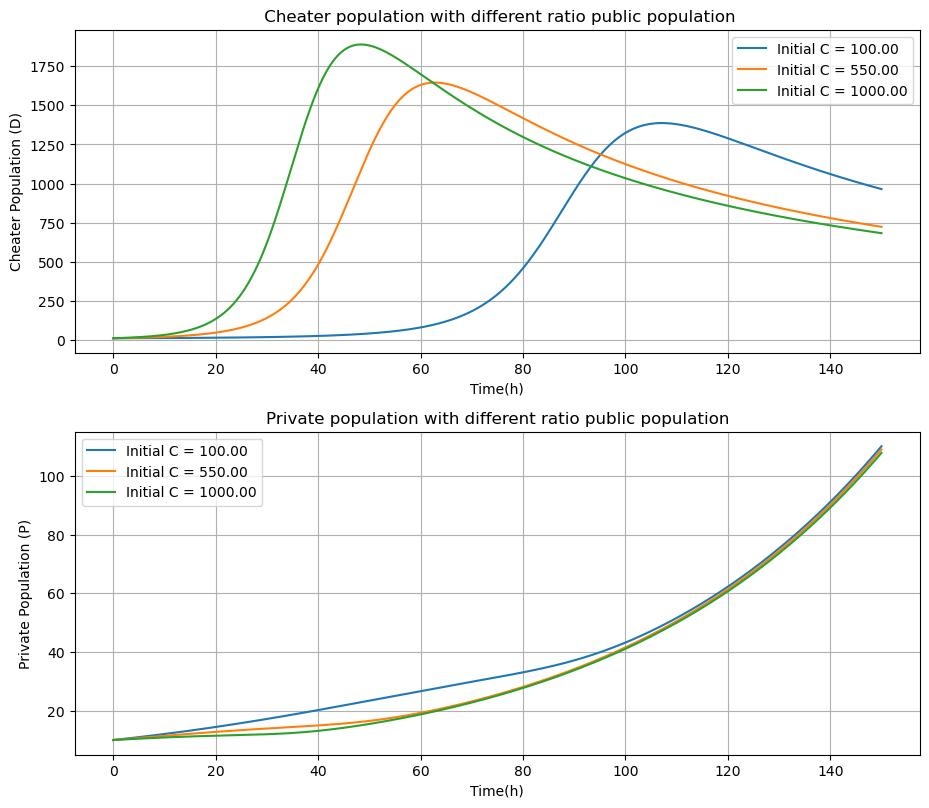

In [51]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Fixed initial population for cheater (defector) and private
D0 = 10.0
P0 = 10.0

# Range of initial populations for cooperators (C)
C_values = np.linspace(100, 1000, 3)  # C values from 50 to 150

# Time grid
t = np.linspace(0, 150, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, C0 in enumerate(C_values):
    y0 = C0, D0, P0  # Set initial conditions with varying C0 and fixed D0, P0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T


    plt.subplot(3, 2, 3)
    plt.plot(t, D, label=f'Initial P = {C0:.2f}')
    plt.xlabel('Time(h)')
    plt.ylabel('Cheater Population (D)')
    plt.title(' Cheater population with different ratio public population')
    plt.grid(True)

    plt.subplot(3, 2, 5)
    plt.plot(t, P, label=f'Initial C = {C0:.2f}')
    plt.xlabel('Time(h)')
    plt.ylabel('Private Population (P)')
    plt.title('Private population with different ratio public population')
    plt.grid(True)

# Add legends to the plots
plt.subplot(3, 2, 3)
plt.legend()
plt.subplot(3, 2, 5)
plt.legend()

plt.tight_layout()
plt.show()


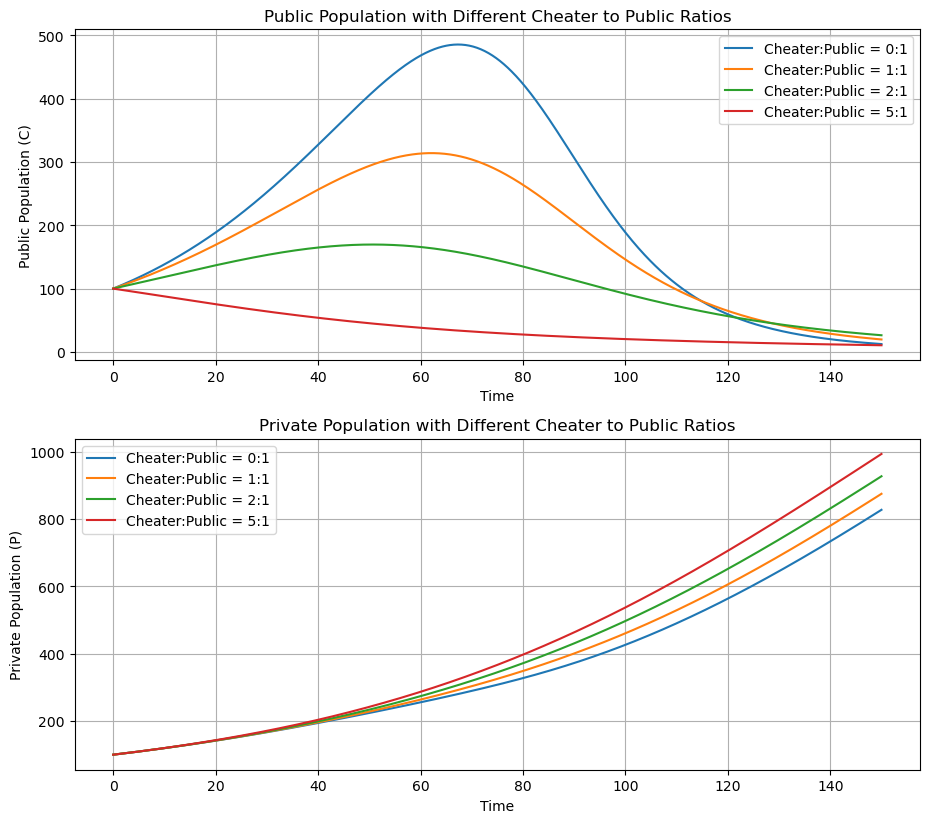

In [67]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of cheater to public population ratios
ratios = [1, 2, 5]  # D/C ratios (cheater to public ratio)

# Initial conditions
C0 = 100.0  # Initial public population (C)
P0 = 100.0   # Initial private population (P)

# Time grid
t = np.linspace(0, 150, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, ratio in enumerate(ratios):
    D0 = C0 * ratio  # Set the initial cheater population based on ratio (D0 = C0 * ratio)
    y0 = C0, D0, P0  # Initial conditions: C0, D0, P0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for public population (C)
    plt.subplot(3, 2, 1)
    plt.plot(t, C, label=f'Cheater:Public = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Public Population (C)')
    plt.title('Public Population with Different Cheater to Public Ratios')
    plt.grid(True)

    # Plot time-series for private population (P)
    plt.subplot(3, 2, 3)
    plt.plot(t, P, label=f'Cheater:Private = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Private Population (P)')
    plt.title('Private Population with Different Cheater to Public Ratios')
    plt.grid(True)

# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()
plt.subplot(3, 2, 3)
plt.legend()

plt.tight_layout()
plt.show()


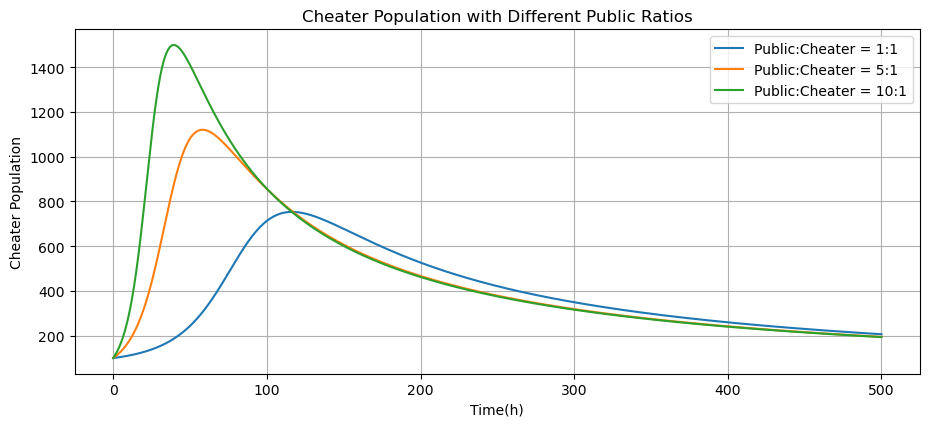

In [72]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of public to cheater population ratios
ratios = [1, 5, 10]  # C/D ratios (public to cheater ratio)

# Initial conditions
D0 = 100.0  # Constant initial cheater population (D)
P0 = 100.0   # Initial private population (P)

# Time grid
t = np.linspace(0, 500, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, ratio in enumerate(ratios):
    C0 = D0 * ratio  # Set the initial public population based on the ratio (C0 = D0 * ratio)
    y0 = C0, D0, P0  # Initial conditions: C0, D0, P0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for public population (C)
    plt.subplot(3, 2, 1)
    plt.plot(t, D, label=f'Public:Cheater = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Cheater Population')
    plt.title('Cheater Population with Different Public Ratios')
    plt.grid(True)


# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()

plt.tight_layout()
plt.show()
